In [7]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

In [8]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# affect color feature

# 1. original

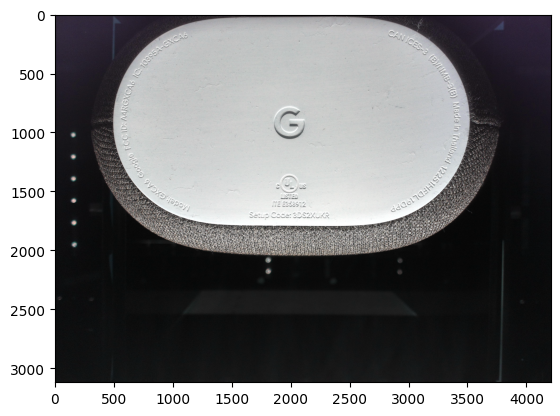

In [12]:
# read random image
dir = "samples/org"
# path = random.choice(os.listdir(dir))
img = cv2.imread("Google Nest Audio.jpg")
plt.imshow(img)

(3104, 4192)


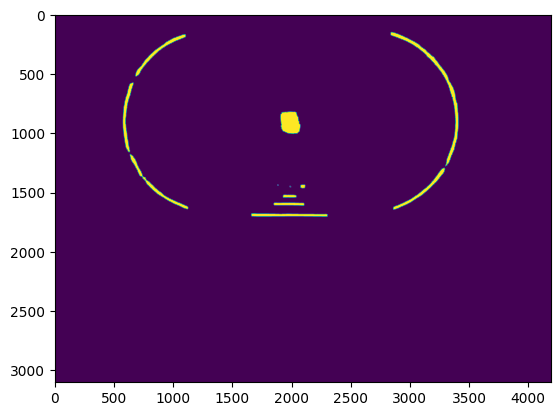

In [14]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)

# 1. grey

Text(0.5, 1.0, 'grey_27.jpg')

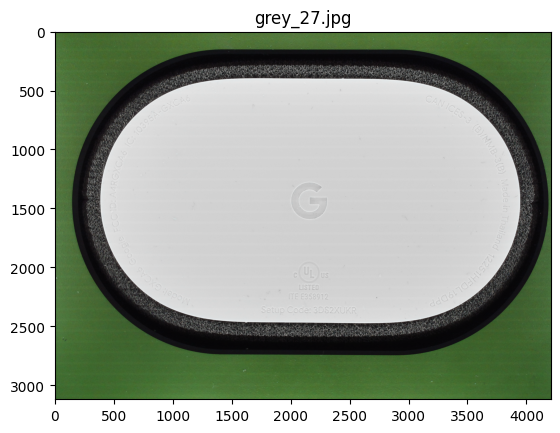

In [85]:
# read random image
dir = "samples/grey"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'grey_27.jpg')

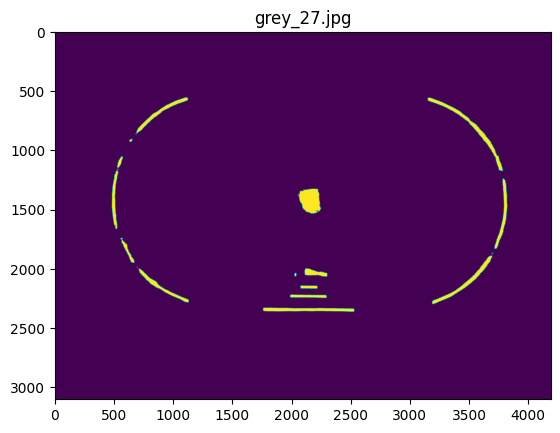

In [86]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 2. blue

Text(0.5, 1.0, 'blue_67.jpg')

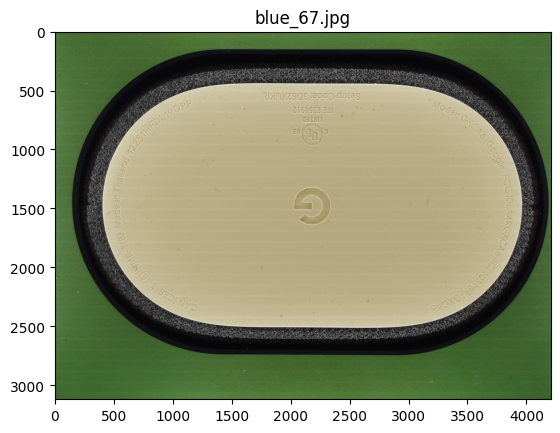

In [87]:
# read random image
dir = "samples/blue"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'blue_67.jpg')

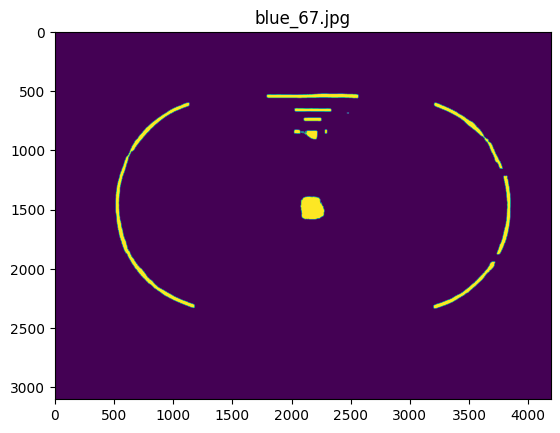

In [88]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 3.green

Text(0.5, 1.0, 'green_60.jpg')

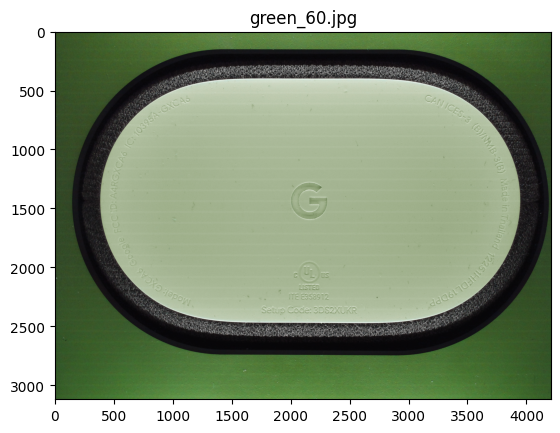

In [89]:
# read random image
dir = "samples/green"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'green_60.jpg')

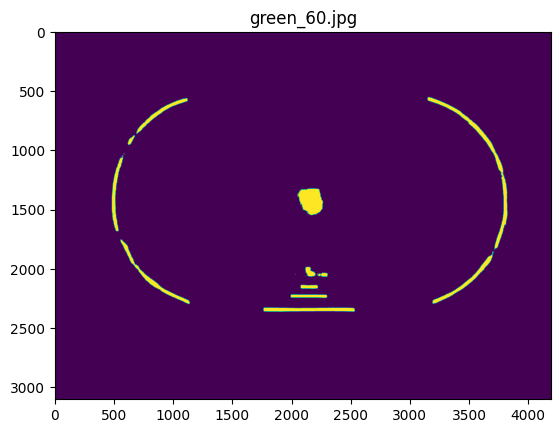

In [90]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 4.pink

Text(0.5, 1.0, 'pink_60.jpg')

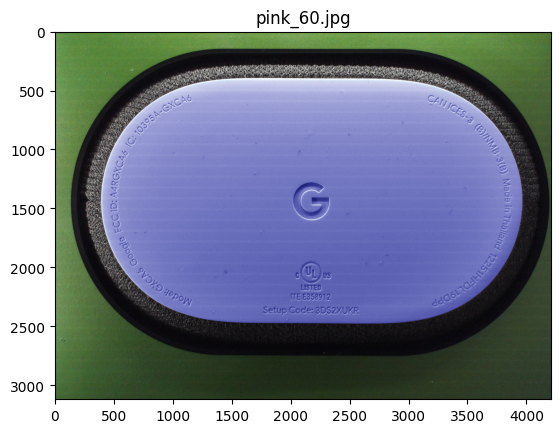

In [190]:
# read random image
dir = "samples/pink"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'pink_60.jpg')

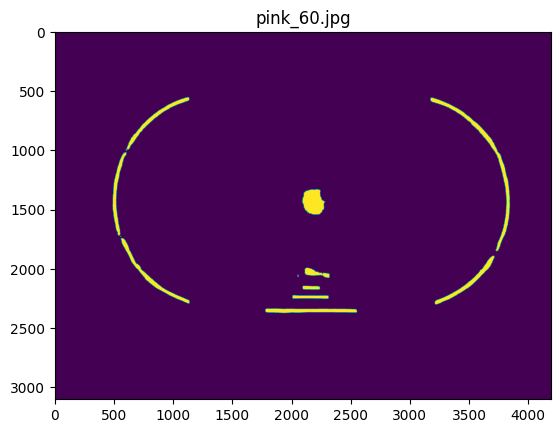

In [191]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

In [192]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"number of contours: {len(contours)}")

number of contours: 84


Text(0.5, 1.0, 'pink_60.jpg')

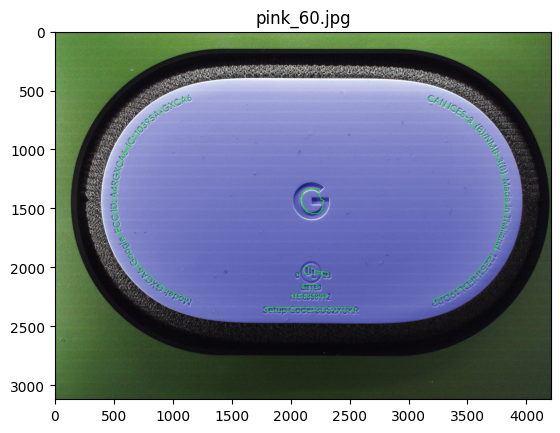

In [193]:
img = cv2.drawContours(img,contours, -1, (0,255,0), 3)
plt.imshow(img)
plt.title(path)

boxs 84


Text(0.5, 1.0, 'pink_60.jpg')

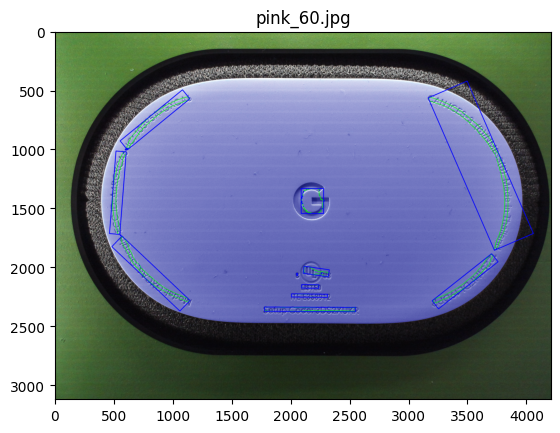

In [194]:
boxs = []

for cnt in contours:
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int0(box)
    boxs.append(box)
    cv2.drawContours(img,[box],0,(0,0,255),6)

print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title(path)
#cv2.imwrite("rr.jpg",img)

# read image

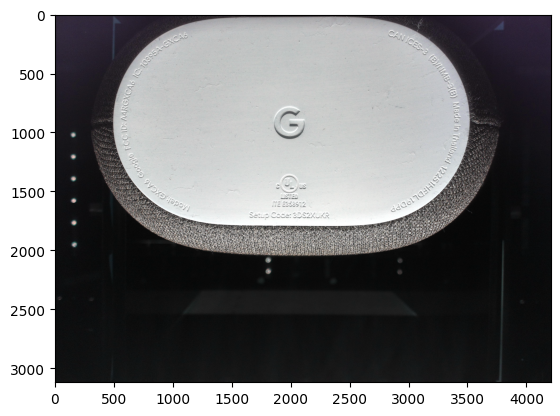

In [117]:
dir = "samples/org"
img = cv2.imread("Google Nest Audio.jpg")
plt.imshow(img)

(3104, 4192)


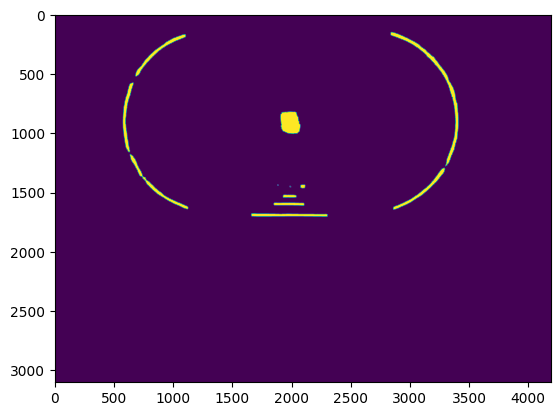

In [118]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)

# detect rr (rotated rectangle)

In [119]:
import os
import cv2
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

In [120]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"number of contours: {len(contours)}")

number of contours: 47


In [121]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [122]:
print(areas)

[13026.0, 5077.0, 2268.5, 1.5, 29.5, 1.0, 1.0, 2.5, 0.0, 970.0, 26.5, 13533.5, 5.0, 0.0, 15273.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 25737.5, 7.0, 2.0, 5.5, 7.0, 7.0, 7.0, 2.0, 13.5, 6.0, 6.0, 6.0, 0.0, 0.0, 10.0, 14668.5, 0.0, 13721.0, 36064.0, 2.0, 2.0]


In [123]:
print(np.array(areas).mean())

2989.255319148936


In [124]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

In [125]:
print(len(cnts))

8


8
boxs 8


Text(0.5, 1.0, 'greater then mean rotated rectangle')

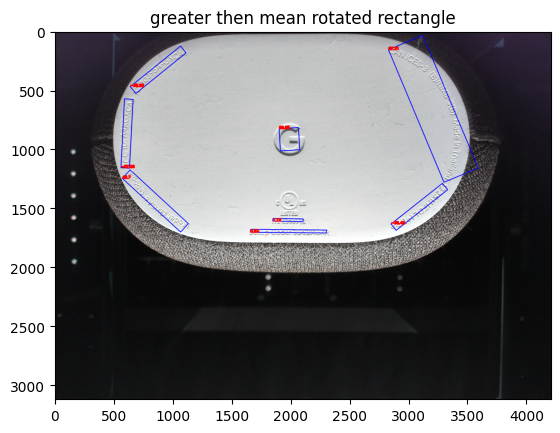

In [126]:
boxs = []
angles = [] # degree
for cnt in cnts:
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int0(box)
    boxs.append(box)
    # calcuate angle
    origin = box[0]
    rect_width, rect_height = rect[1]
    if rect_width > rect_height:
         target = box[3]
    else:
         target = box[1]
    dv = target[1] - origin[1]
    du = target[0] - origin[0]
    angle = math.atan2(dv, du)
    angle = angle*180/np.pi
    angles.append(angle)
    # draw
    cv2.drawContours(img,[box],0,(0,0,255),6)
    cv2.putText(img,f"{round(angle,2)}",box[0],cv2.FONT_HERSHEY_SIMPLEX,1,(255,0,0),10, cv2.LINE_AA)

print(len(boxs))
print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")
# cv2.imwrite("img.jpg",img)

In [131]:
angles

[0.5346262827943352,
 1.1189159305671887,
 -38.41805534482199,
 42.704562610543924,
 86.65140518554311,
 -87.05930853121356,
 -38.921281758990666,
 67.30778279907668]

In [132]:
boxs

[array([[1654, 1706],
        [1655, 1681],
        [2298, 1687],
        [2297, 1712]]),
 array([[1844, 1611],
        [1845, 1588],
        [2101, 1593],
        [2100, 1616]]),
 array([[2845, 1636],
        [3280, 1291],
        [3324, 1345],
        [2888, 1690]]),
 array([[ 570, 1249],
        [ 636, 1177],
        [1129, 1633],
        [1063, 1704]]),
 array([[1897,  828],
        [2061,  818],
        [2072, 1006],
        [1908, 1016]]),
 array([[ 558, 1159],
        [ 588,  575],
        [ 661,  579],
        [ 630, 1163]]),
 array([[ 637,  471],
        [1063,  127],
        [1109,  185],
        [ 684,  529]]),
 array([[2823,  158],
        [3113,   36],
        [3583, 1161],
        [3293, 1282]])]

In [133]:
box.shape

(4, 2)

In [134]:
# find center of rec
print(box[0]+box[2])
print(box[1]+box[3])

[6406 1319]
[6406 1318]


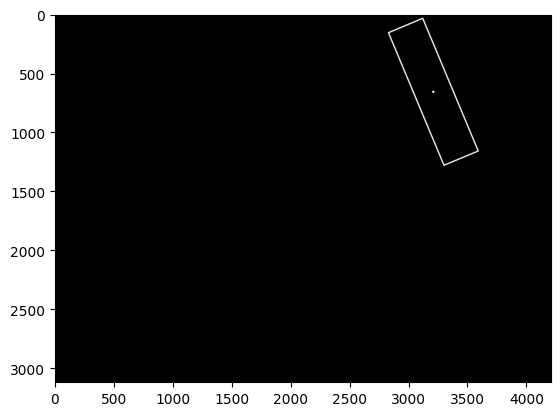

In [135]:
avg = (box[0]+box[2])/2
cx = int(avg[0])
cy = int(avg[1])

blank = np.zeros_like(img)
# display result
cv2.polylines(blank, [box.reshape(-1,1,2)],True,(255,255,255),10)
cv2.circle(blank,(cx,cy),10,(255,255,255),-1)
plt.imshow(blank)

# rotate and crop

In [206]:
img = cv2.imread("Google Nest Audio.jpg")

In [208]:
h,w,c = img.shape

In [225]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    oldY,oldX,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(oldX/2,oldY/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    newX,newY = oldX*scaleFactor,oldY*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    newX,newY = (abs(np.sin(r)*newY) + abs(np.cos(r)*newX),abs(np.sin(r)*newX) + abs(np.cos(r)*newY))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((newX-oldX)/2,(newY-oldY)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(newX),int(newY)))
    return rotatedImg

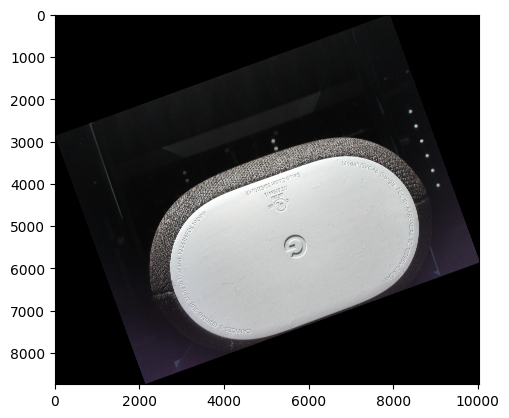

In [236]:
image = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = 200)
plt.imshow(image)

# padding

# references

[after-rotation-window-doesnt-fit-image](https://stackoverflow.com/questions/11764575/python-2-7-3-opencv-2-4-after-rotation-window-doesnt-fit-image)

[skew for ocr](https://stackoverflow.com/questions/57964634/python-opencv-skew-correction-for-ocr)

[How to straighten a rotated rectangle area of an image using OpenCV in Python?](https://stackoverflow.com/questions/11627362/how-to-straighten-a-rotated-rectangle-area-of-an-image-using-opencv-in-python)

[Order of corners in a rotating rectangle in OpenCV Python](https://stackoverflow.com/questions/69074165/order-of-corners-in-a-rotating-rectangle-in-opencv-python)

[rectangle formular](https://structx.com/Shape_Formulas_033.html)

[rotated rectangle](https://namkeenman.wordpress.com/2015/12/18/open-cv-determine-angle-of-rotatedrect-minarearect/)

[theailearner](https://theailearner.com/tag/cv2-minarearect/)

[circle-fit](https://pypi.org/project/circle-fit/)